# Análisis Espacial de Hogares en CABA - Censo 2022

En este notebook vamos a realizar un análisis espacial de los datos censales de hogares en la Ciudad Autónoma de Buenos Aires (CABA) del año 2022.

## Objetivos
- Explorar la distribución espacial de hogares propietarios e inquilinos
- Identificar patrones de concentración espacial (hot spots y cold spots)
- Aplicar técnicas de autocorrelación espacial local (Gi*)

## 1. Importación de librerías y carga de datos

Comenzamos importando las librerías necesarias para el análisis espacial y la visualización de datos.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from libpysal.weights import Queen
from esda.getisord import G_Local
import statsmodels.api as sm

%matplotlib inline
plt.rcParams["figure.figsize"] = (16, 12)

# Carga de datos
hogar_caba = gpd.read_file('data/Indicadores de hogares. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA)/Indicadores de hogares. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA).shp')
personas_caba = gpd.read_file('data/Indicadores de personas. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA)/Indicadores de personas. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA).shp')
barrios_caba = gpd.read_file('data/barrios.shp')

C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Exploración de las columnas disponibles

Antes de comenzar el análisis, exploramos las columnas disponibles en el dataset de hogares para identificar las variables de interés.

In [2]:
#print(personas_caba.columns)
print(hogar_caba.columns)   

Index(['REDCODE', 'H_TOTAL', 'H_NBI', 'H_COMPUTAD', 'H_DOMESTIC', 'H_HACINAMI',
       'H_HACINA_1', 'H_CADENA', 'H_AGUA_RED', 'H_AGUA_VIV', 'H_CLOACA',
       'H_HOYO', 'H_TECHO', 'H_CIELORRA', 'H_PISO', 'H_CELULAR', 'H_COMBUSTI',
       'H_PROPIETA', 'H_INQUILIN', 'H_NI_PROPI', 'H_JEFE_MUJ', 'H_JEFE_LIM',
       'H_JEFE_SOL', 'H_JEFE_S_1', 'H_JEFE_SEC', 'H_JEFE_TER', 'H_JEFE_UNI',
       'H_CONYUGE_', 'H_ESTRUCTU', 'H_ESTRUC_1', 'H_ESTRUC_2', 'H_ESTRUC_3',
       'H_ESTRUC_4', 'H_ESTRUC_5', 'H_ESTRUC_6', 'H_TAMANIO_', 'H_TAMANI_1',
       'H_TAMANI_2', 'H_TAMANI_3', 'H_TAMANI_4', 'CODPROV', 'PROV', 'CODDPTO',
       'DPTO', 'REDCODE_1', 'RADIO', 'RADIOS_POB', 'RADIOS_HOG', 'RADIOS_LAT',
       'RADIOS_LON', 'RADIOS_SUP', 'geometry'],
      dtype='object')


## 3. Visualización del total de hogares

Creamos un primer mapa coroplético para visualizar la distribución del total de hogares por radio censal en CABA.

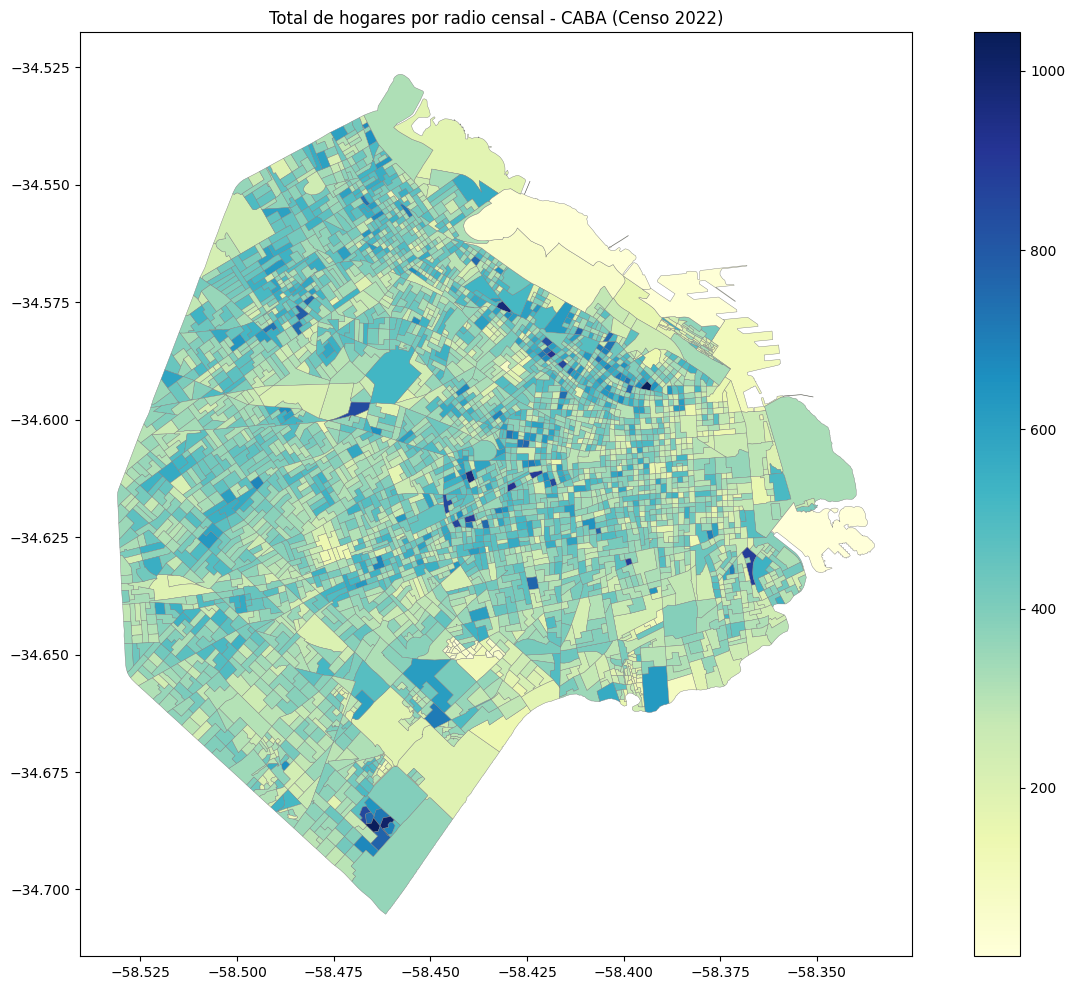

In [3]:
hogar_caba.plot(
    column="H_TOTAL",
    cmap="YlGnBu",
    linewidth=0.3,
    edgecolor="gray",
    legend=True
)

plt.title("Total de hogares por radio censal - CABA (Censo 2022)")
plt.show()

## 4. Comparación: Hogares propietarios vs inquilinos (valores absolutos)

Visualizamos lado a lado la distribución de hogares propietarios e inquilinos en valores absolutos para identificar patrones espaciales iniciales.

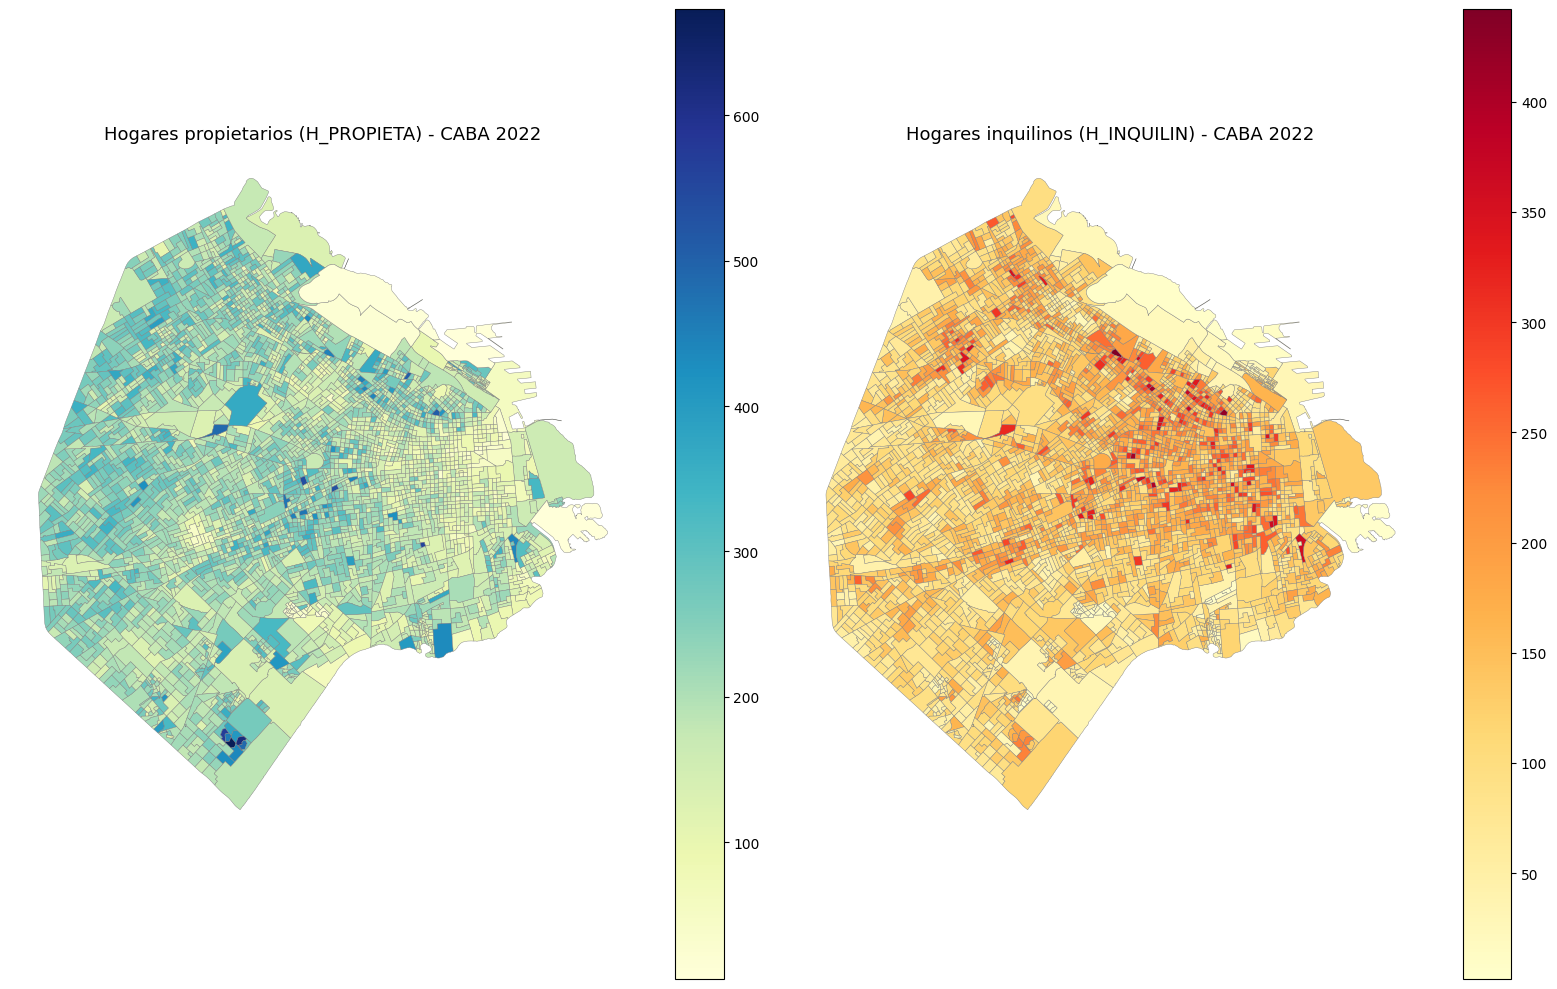

In [4]:
# Configurar la figura
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- Mapa 1: Hogares propietarios ---
hogar_caba.plot(
    column="H_PROPIETA",
    cmap="YlGnBu",
    linewidth=0.3,
    edgecolor="gray",
    legend=True,
    ax=axes[0]
)
axes[0].set_title("Hogares propietarios (H_PROPIETA) - CABA 2022", fontsize=13)
axes[0].axis("off")

# --- Mapa 2: Hogares inquilinos ---
hogar_caba.plot(
    column="H_INQUILIN",
    cmap="YlOrRd",
    linewidth=0.3,
    edgecolor="gray",
    legend=True,
    ax=axes[1]
)
axes[1].set_title("Hogares inquilinos (H_INQUILIN) - CABA 2022", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Cálculo de proporciones

Para realizar un análisis más robusto, calculamos las proporciones de hogares inquilinos y propietarios respecto al total de hogares en cada radio censal. Esto nos permite comparar áreas con diferentes tamaños poblacionales.

In [5]:
# para trabajar con proporciones

hogar_caba["pct_inquilinos"] = hogar_caba["H_INQUILIN"] / hogar_caba["H_TOTAL"]
hogar_caba["pct_propietarios"] = hogar_caba["H_PROPIETA"] / hogar_caba["H_TOTAL"]

## 6. Visualización de proporciones

Comparamos las proporciones de hogares propietarios e inquilinos. Este mapa nos da una mejor perspectiva de la distribución relativa, independientemente del tamaño de cada radio censal.

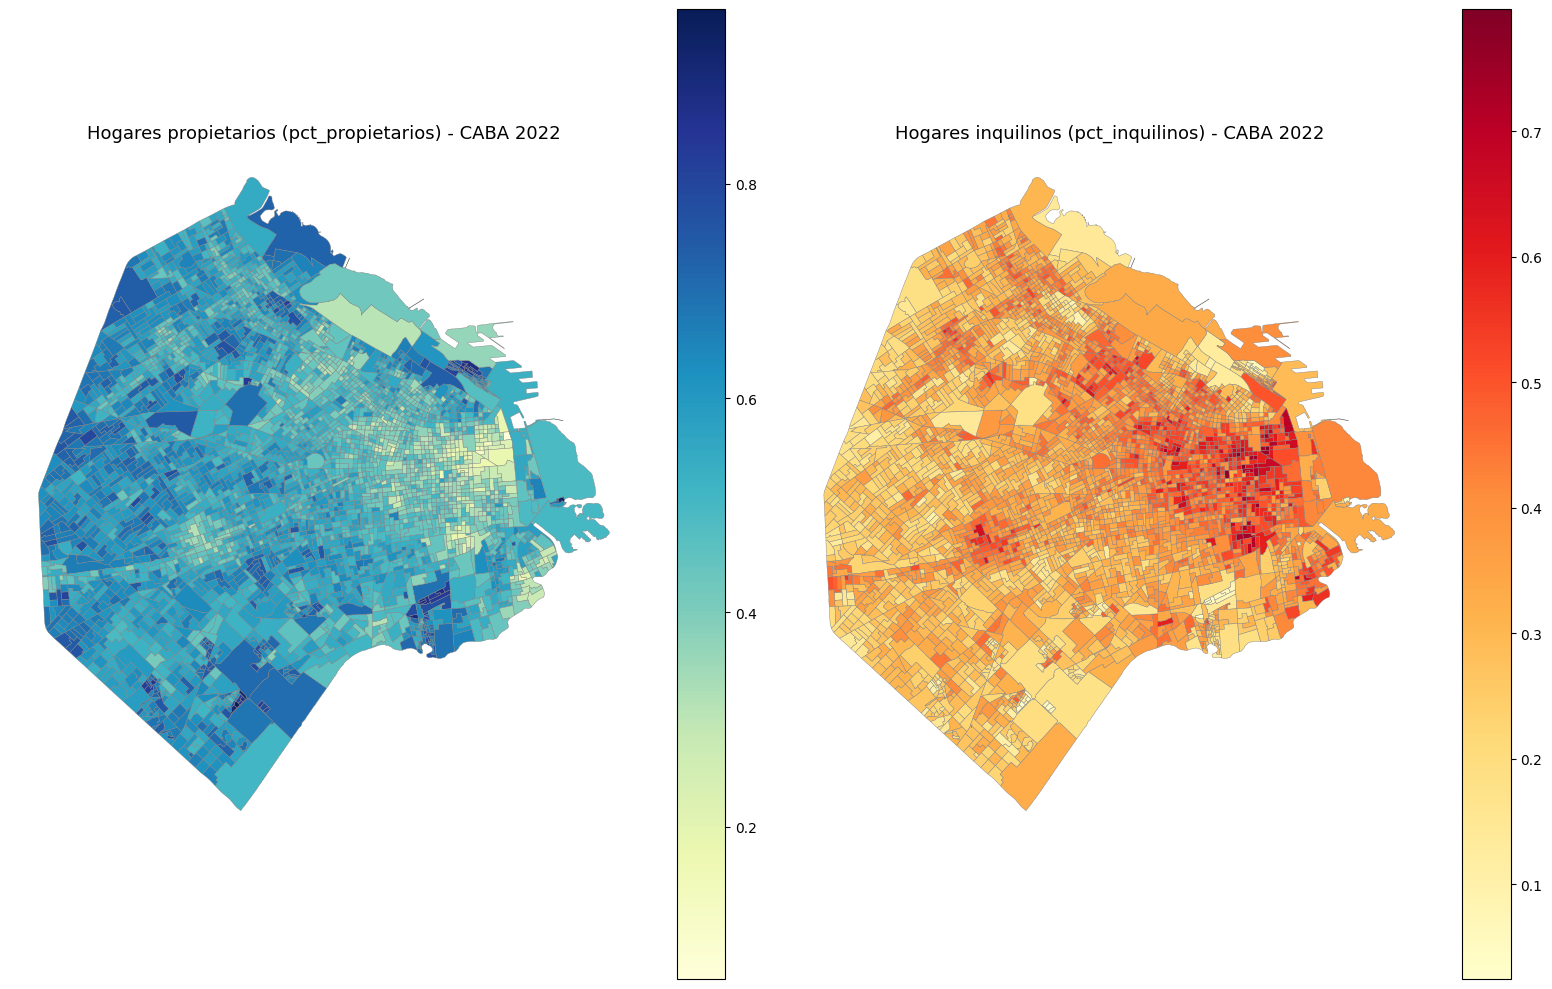

In [6]:
# Configurar la figura
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- Mapa 1: Hogares propietarios ---
hogar_caba.plot(
    column="pct_propietarios",
    cmap="YlGnBu",
    linewidth=0.3,
    edgecolor="gray",
    legend=True,
    ax=axes[0]
)
axes[0].set_title("Hogares propietarios (pct_propietarios) - CABA 2022", fontsize=13)
axes[0].axis("off")

# --- Mapa 2: Hogares inquilinos ---
hogar_caba.plot(
    column="pct_inquilinos",
    cmap="YlOrRd",
    linewidth=0.3,
    edgecolor="gray",
    legend=True,
    ax=axes[1]
)
axes[1].set_title("Hogares inquilinos (pct_inquilinos) - CABA 2022", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 7. Análisis de autocorrelación espacial local - Getis-Ord Gi*

### ¿Qué es Gi*?
El estadístico Getis-Ord Gi* nos permite identificar **hot spots** (concentraciones de valores altos) y **cold spots** (concentraciones de valores bajos) que son estadísticamente significativos.

### Preparación de la matriz de pesos espaciales
Primero, creamos una matriz de pesos espaciales usando el criterio de contigüidad Queen (vecinos que comparten borde o vértice).

In [7]:
# Preparamos los datos y la matriz de pesos espaciales
g = hogar_caba.copy()
g = g[g["H_TOTAL"] > 0]  # evitar divisiones por cero

# Crear matriz de pesos espaciales usando criterio Queen
w = Queen.from_dataframe(g)

C:\Users\tomas\AppData\Local\Temp\ipykernel_17760\204234845.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(g)


### 7.1. Análisis con estandarización binaria (B)

La estandarización binaria (B) es la forma clásica para Gi*. Testea si la **suma local** de valores es significativamente diferente de la suma global.

**Interpretación:**
- **Hot spots (rojo)**: Áreas donde tanto el radio como sus vecinos tienen valores altos
- **Cold spots (azul)**: Áreas donde tanto el radio como sus vecinos tienen valores bajos
- **No significativo (gris)**: Áreas sin patrón espacial significativo (p ≥ 0.05)

Islas (sin vecinos): 0


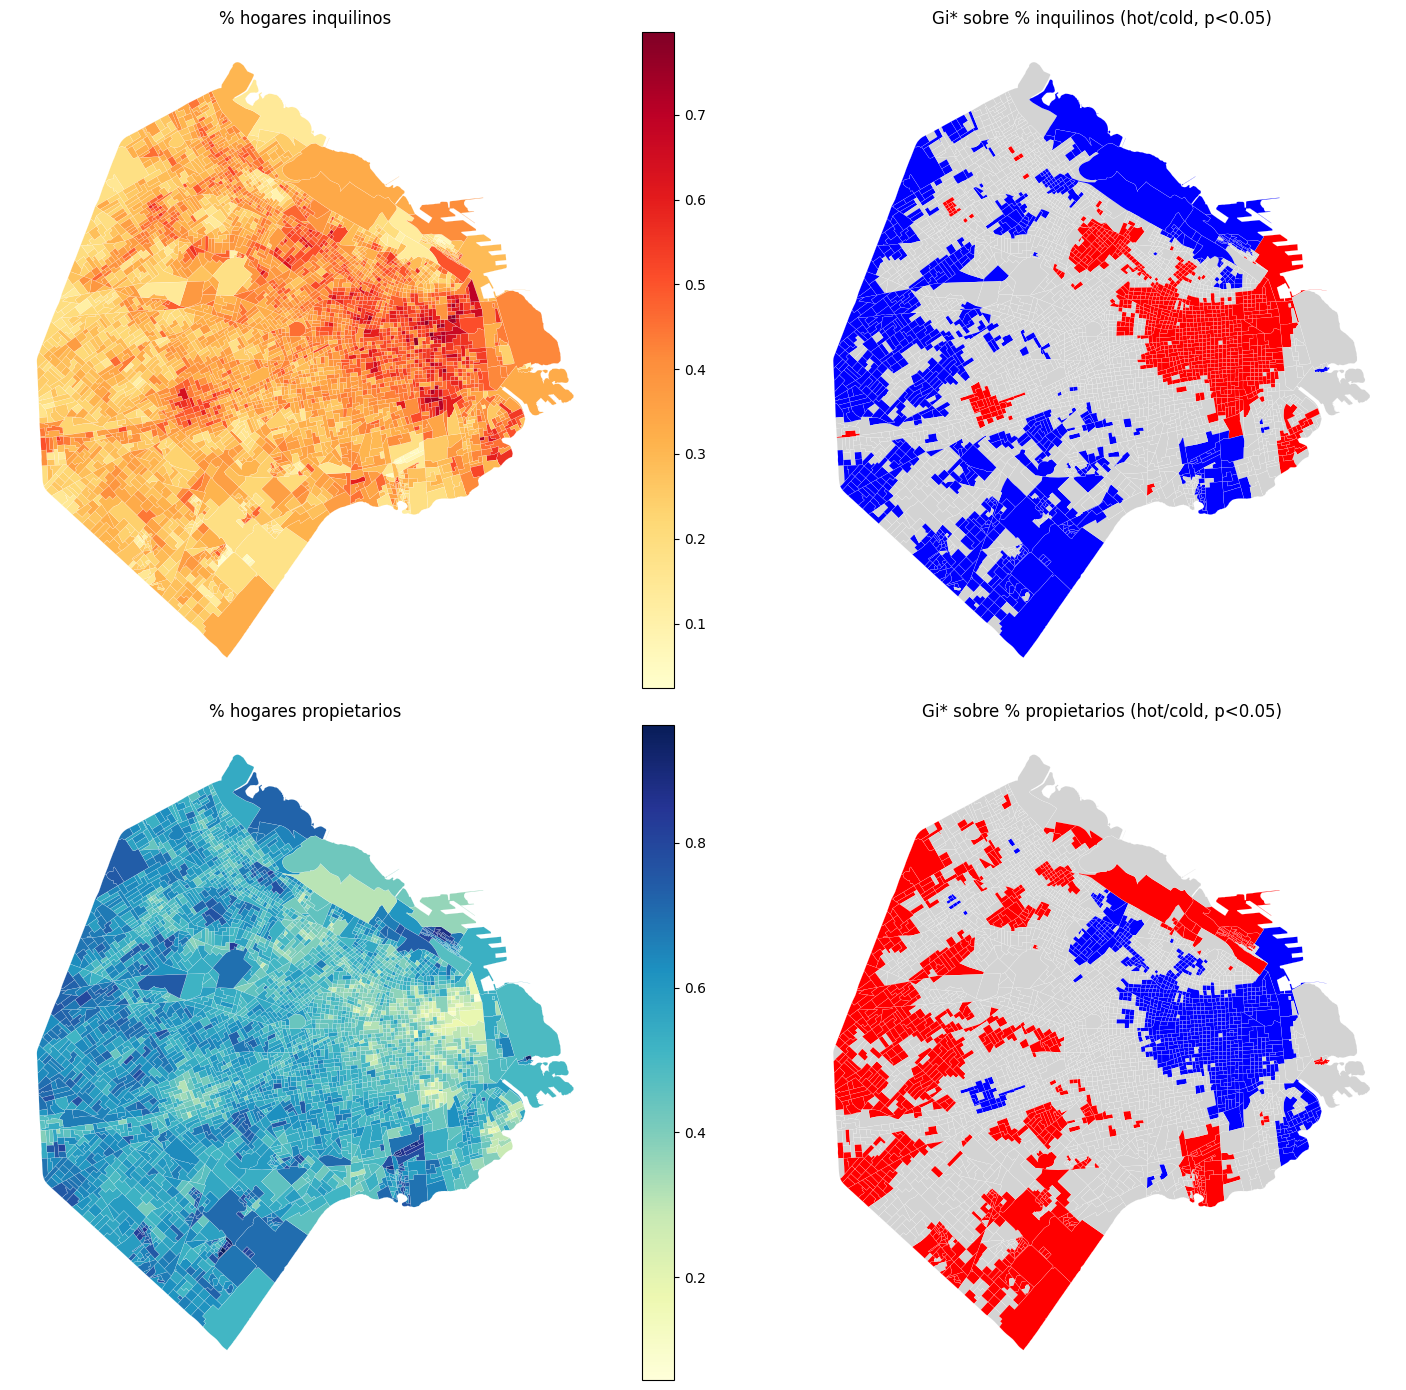

In [8]:
# Opciones de estandarización de pesos:
# - 'B' = binarios (clásico para Gi*; testea "suma" local frente a global)
# - 'R' = row-standardized (promedio local; menos sensible al # de vecinos)
w.transform = "B"   # <-- Cambiá a "R" si querés comparar

print(f"Islas (sin vecinos): {len(w.islands)}")
# Si hubiera islas y preferís forzar al menos 1 vecino, te paso un fix luego.

# 3) Gi* para % de hogares inquilinos
gi_inq = G_Local(g["pct_inquilinos"].values, w, star=True, permutations=999)
g["GiZ_inq"] = gi_inq.Zs          # z-score local (positivo=hot, negativo=cold)
g["p_inq"]   = gi_inq.p_sim       # p-valor por permutaciones

g["clase_inq"] = "ns"
g.loc[(g["p_inq"] < 0.05) & (g["GiZ_inq"] > 0), "clase_inq"] = "hot"
g.loc[(g["p_inq"] < 0.05) & (g["GiZ_inq"] < 0), "clase_inq"] = "cold"

# 4) Gi* para % de hogares propietarios
gi_prop = G_Local(g["pct_propietarios"].values, w, star=True, permutations=999)
g["GiZ_prop"] = gi_prop.Zs
g["p_prop"]   = gi_prop.p_sim

g["clase_prop"] = "ns"
g.loc[(g["p_prop"] < 0.05) & (g["GiZ_prop"] > 0), "clase_prop"] = "hot"
g.loc[(g["p_prop"] < 0.05) & (g["GiZ_prop"] < 0), "clase_prop"] = "cold"

# 5) Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# % inquilinos (coroplético)
g.plot(column="pct_inquilinos", cmap="YlOrRd", legend=True,
       edgecolor="white", linewidth=0.1, ax=axes[0,0])
axes[0,0].set_title("% hogares inquilinos")
axes[0,0].axis("off")

# Gi* inquilinos (hot/cold)
colors = {"hot":"red", "cold":"blue", "ns":"lightgrey"}
g.assign(_color=g["clase_inq"].map(colors)).plot(color=g["clase_inq"].map(colors),
       edgecolor="white", linewidth=0.1, ax=axes[0,1])
axes[0,1].set_title("Gi* sobre % inquilinos (hot/cold, p<0.05)")
axes[0,1].axis("off")

# % propietarios (coroplético)
g.plot(column="pct_propietarios", cmap="YlGnBu", legend=True,
       edgecolor="white", linewidth=0.1, ax=axes[1,0])
axes[1,0].set_title("% hogares propietarios")
axes[1,0].axis("off")

# Gi* propietarios (hot/cold)
g.assign(_color=g["clase_prop"].map(colors)).plot(color=g["clase_prop"].map(colors),
       edgecolor="white", linewidth=0.1, ax=axes[1,1])
axes[1,1].set_title("Gi* sobre % propietarios (hot/cold, p<0.05)")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()

### 7.2. Análisis con estandarización por filas (R)

La estandarización por filas (R) calcula el **promedio local** en lugar de la suma. Es menos sensible al número de vecinos que tiene cada radio censal.

**Diferencias con la estandarización B:**
- Más apropiada cuando los radios tienen diferente número de vecinos
- Enfatiza el promedio de la vecindad en lugar de la suma total
- Puede revelar patrones diferentes, especialmente en áreas con geometrías irregulares

Islas (sin vecinos): 0


C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximu

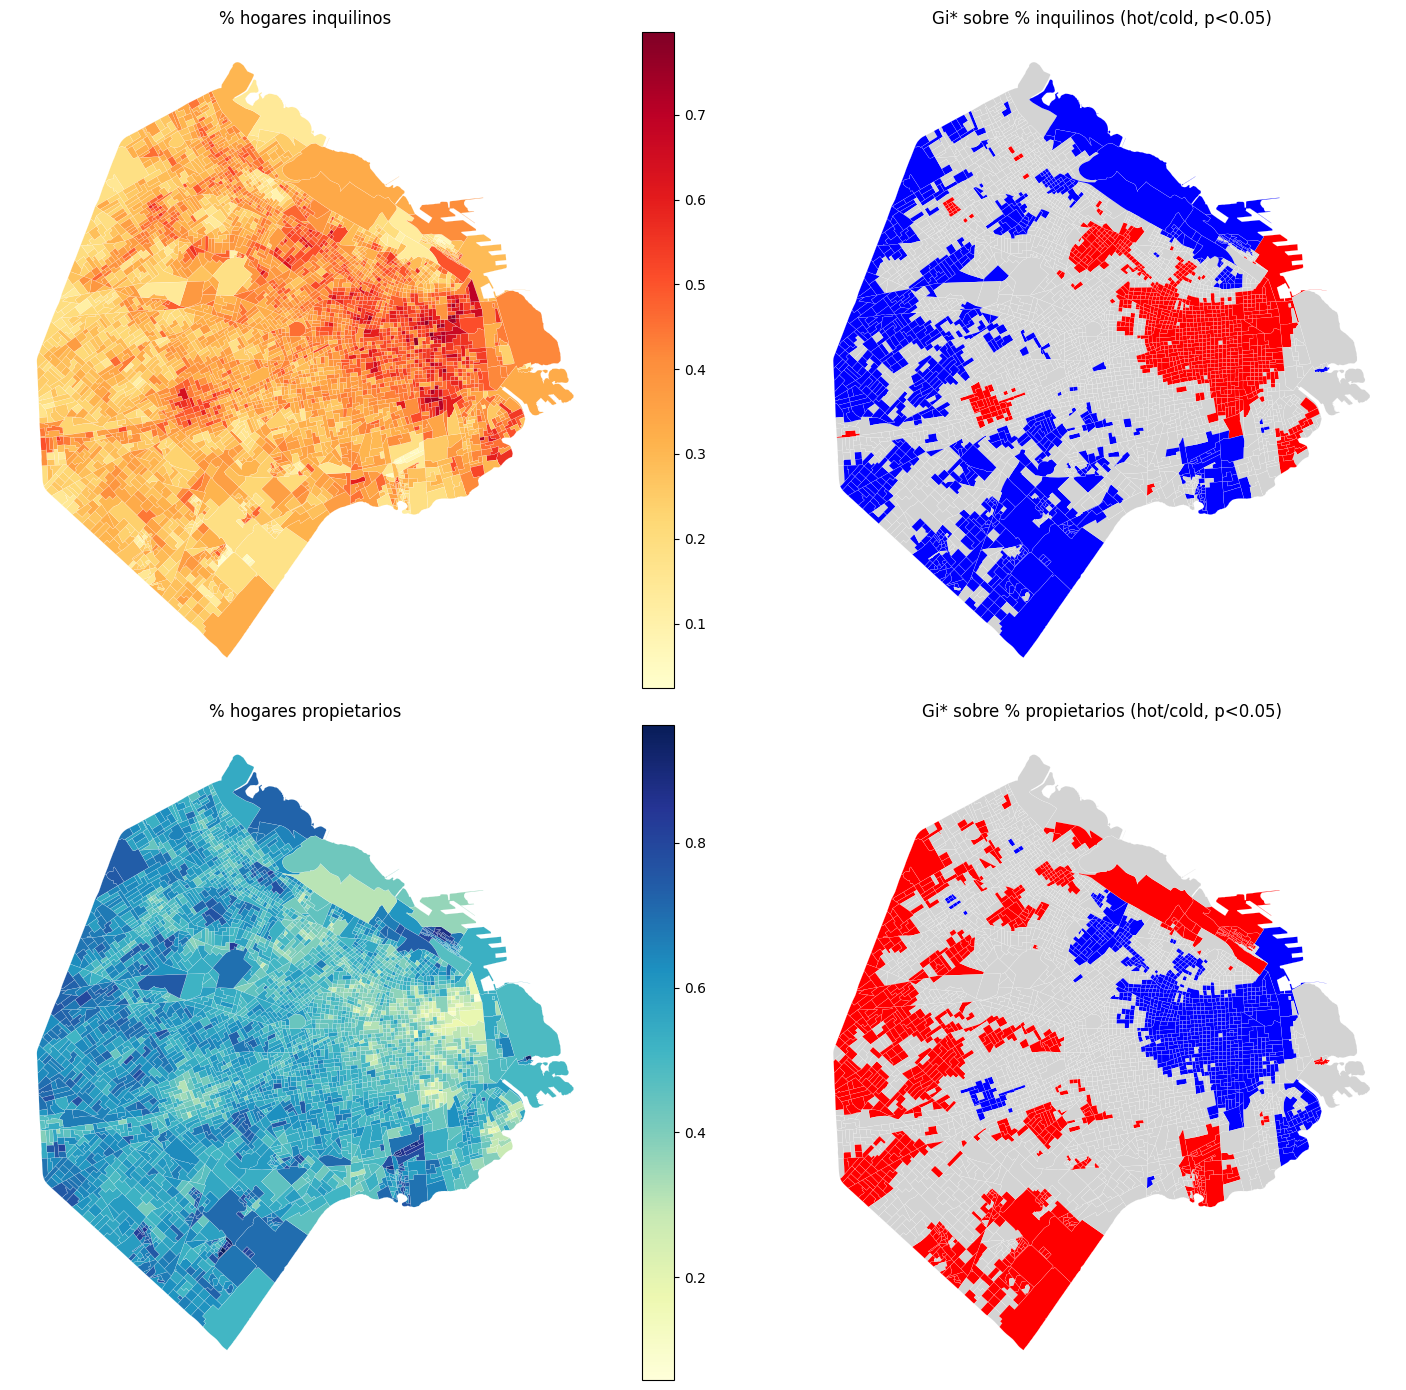

In [9]:
# Opciones de estandarización de pesos:
# - 'B' = binarios (clásico para Gi*; testea "suma" local frente a global)
# - 'R' = row-standardized (promedio local; menos sensible al # de vecinos)
w.transform = "R"   # <-- Cambiá a "R" si querés comparar

print(f"Islas (sin vecinos): {len(w.islands)}")
# Si hubiera islas y preferís forzar al menos 1 vecino, te paso un fix luego.

# 3) Gi* para % de hogares inquilinos
gi_inq = G_Local(g["pct_inquilinos"].values, w, star=True, permutations=999)
g["GiZ_inq"] = gi_inq.Zs          # z-score local (positivo=hot, negativo=cold)
g["p_inq"]   = gi_inq.p_sim       # p-valor por permutaciones

g["clase_inq"] = "ns"
g.loc[(g["p_inq"] < 0.05) & (g["GiZ_inq"] > 0), "clase_inq"] = "hot"
g.loc[(g["p_inq"] < 0.05) & (g["GiZ_inq"] < 0), "clase_inq"] = "cold"

# 4) Gi* para % de hogares propietarios
gi_prop = G_Local(g["pct_propietarios"].values, w, star=True, permutations=999)
g["GiZ_prop"] = gi_prop.Zs
g["p_prop"]   = gi_prop.p_sim

g["clase_prop"] = "ns"
g.loc[(g["p_prop"] < 0.05) & (g["GiZ_prop"] > 0), "clase_prop"] = "hot"
g.loc[(g["p_prop"] < 0.05) & (g["GiZ_prop"] < 0), "clase_prop"] = "cold"

# 5) Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# % inquilinos (coroplético)
g.plot(column="pct_inquilinos", cmap="YlOrRd", legend=True,
       edgecolor="white", linewidth=0.1, ax=axes[0,0])
axes[0,0].set_title("% hogares inquilinos")
axes[0,0].axis("off")

# Gi* inquilinos (hot/cold)
colors = {"hot":"red", "cold":"blue", "ns":"lightgrey"}
g.assign(_color=g["clase_inq"].map(colors)).plot(color=g["clase_inq"].map(colors),
       edgecolor="white", linewidth=0.1, ax=axes[0,1])
axes[0,1].set_title("Gi* sobre % inquilinos (hot/cold, p<0.05)")
axes[0,1].axis("off")

# % propietarios (coroplético)
g.plot(column="pct_propietarios", cmap="YlGnBu", legend=True,
       edgecolor="white", linewidth=0.1, ax=axes[1,0])
axes[1,0].set_title("% hogares propietarios")
axes[1,0].axis("off")

# Gi* propietarios (hot/cold)
g.assign(_color=g["clase_prop"].map(colors)).plot(color=g["clase_prop"].map(colors),
       edgecolor="white", linewidth=0.1, ax=axes[1,1])
axes[1,1].set_title("Gi* sobre % propietarios (hot/cold, p<0.05)")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()

## 8. Análisis de valores absolutos con modelo Poisson

### ¿Por qué usar un modelo Poisson?

Cuando trabajamos con **conteos** (valores absolutos) en lugar de proporciones, debemos considerar que:
- Los radios censales tienen diferentes tamaños poblacionales
- Un radio con más hogares naturalmente tendrá más inquilinos

### Solución: Modelo Poisson con offset

Usamos un modelo GLM Poisson con `offset = log(H_TOTAL)` para:
1. Calcular los valores **esperados** de inquilinos según el tamaño del radio
2. Obtener **residuales estandarizados** (diferencia entre observado y esperado)
3. Aplicar Gi* sobre estos residuales para identificar hot/cold spots

**Interpretación:**
- **Hot spots**: Áreas con más inquilinos de lo esperado dado su tamaño
- **Cold spots**: Áreas con menos inquilinos de lo esperado dado su tamaño

### 8.1. Visualización de hot/cold spots sobre residuales

Este mapa muestra las áreas donde hay un exceso (hot) o déficit (cold) de hogares inquilinos respecto a lo esperado, controlando por el tamaño poblacional de cada radio censal.

### Hot y Cold spots de Valores absolutos

In [10]:
g = hogar_caba.copy()
g = g[g["H_TOTAL"] > 0]  # evitar divisiones por cero

# Poisson con offset = log(H_TOTAL): expectativa proporcional al tamaño
y = g["H_INQUILIN"].astype(float)
X = sm.add_constant(np.ones(len(g)))   # solo intercepto (tasa global)
m = sm.GLM(y, X, family=sm.families.Poisson(), offset=np.log(g["H_TOTAL"]))
fit = m.fit()

g["mu_exp"]     = fit.mu                         # esperados
g["resid_pear"] = (y - g["mu_exp"]) / np.sqrt(g["mu_exp"])  # residuales estandarizados

# Gi* sobre residuales (exceso/defecto local)
w = Queen.from_dataframe(g); w.transform = "R"   # o "B"; con conteos suele convenir "R"
gi = G_Local(g["resid_pear"].values, w, star=True, permutations=999)
g["GiZ_res"] = gi.Zs
g["p_res"]   = gi.p_sim

C:\Users\tomas\AppData\Local\Temp\ipykernel_17760\1851957046.py:14: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(g); w.transform = "R"   # o "B"; con conteos suele convenir "R"
C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


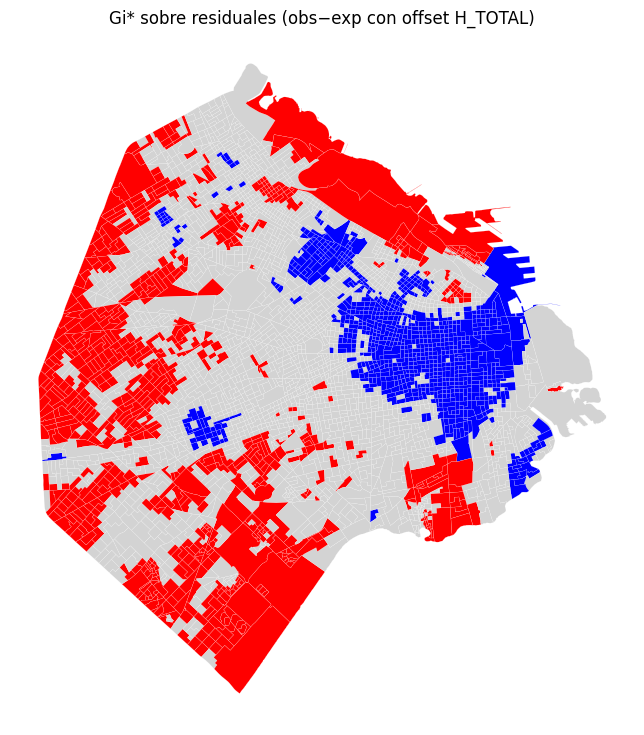

In [11]:

g["cls"] = "ns"
g.loc[(g["p_res"]<0.05) & (g["GiZ_res"]>0), "cls"] = "hot"
g.loc[(g["p_res"]<0.05) & (g["GiZ_res"]<0), "cls"] = "cold"

fig, ax = plt.subplots(figsize=(9,9))
colors = {"hot":"red","cold":"blue","ns":"lightgrey"}
g.plot(color=g["cls"].map(colors), edgecolor="white", linewidth=0.1, ax=ax)
ax.set_title("Gi* sobre residuales (obs−exp con offset H_TOTAL)")
ax.axis("off")
plt.show()